In [1]:
!pip install torch torchvision tqdm scikit-learn

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
import json
import random
from collections import defaultdict
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ==============================
# Reproducibility
# ==============================
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# ==============================
# Device
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print("Using device:", device)

# ==============================
# Hyperparameters
# ==============================
BATCH_SIZE = 128
EPOCHS = 20
LR = 1e-3
NUM_CLASSES = 10
NUM_WORKERS = 2

OUTPUT_DIR = "colab_resnet_wo_skip"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "plots"), exist_ok=True)

Using device: cuda


In [3]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.4377, 0.4438, 0.4728],
                         [0.1980, 0.2010, 0.1970])
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.4377, 0.4438, 0.4728],
                         [0.1980, 0.2010, 0.1970])
])

train_ds = datasets.SVHN(root="./data", split="train",
                         download=True, transform=transform_train)

test_ds = datasets.SVHN(root="./data", split="test",
                        download=True, transform=transform_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=NUM_WORKERS,
                          pin_memory=True)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=NUM_WORKERS,
                         pin_memory=True)

100%|██████████| 182M/182M [00:13<00:00, 13.6MB/s]
100%|██████████| 64.3M/64.3M [00:02<00:00, 30.3MB/s]


In [4]:
class PlainBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_c, out_c, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_c)

        self.conv2 = nn.Conv2d(out_c, out_c, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_c)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        return x

In [5]:
class PlainResNet20(nn.Module):
    def __init__(self):
        super().__init__()

        self.initial = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.layer1 = self._make_layer(64, 64, 3, 1)
        self.layer2 = self._make_layer(64, 128, 3, 2)
        self.layer3 = self._make_layer(128, 256, 3, 2)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(256, NUM_CLASSES)

        self._initialize()

    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [PlainBlock(in_c, out_c, stride)]
        for _ in range(1, blocks):
            layers.append(PlainBlock(out_c, out_c))
        return nn.Sequential(*layers)

    def _initialize(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight,
                                        mode="fan_out",
                                        nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.initial(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

In [6]:
model = PlainResNet20().to(device)

TRACKED_LAYERS = {
    "initial": model.initial[0],
    "layer1": model.layer1[0].conv1,
    "layer2": model.layer2[0].conv1,
    "layer3": model.layer3[0].conv1,
}

history = {
    "train_acc": [],
    "test_acc": [],
    "epoch_grad_norms": {k: [] for k in TRACKED_LAYERS},
    "weight_norms": {k: [] for k in TRACKED_LAYERS},
    "weight_deltas": {k: [] for k in TRACKED_LAYERS},
}

prev_weights = {k: v.weight.data.clone()
                for k,v in TRACKED_LAYERS.items()}

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, 10, 0.5)

def train_epoch():
    model.train()
    correct = total = 0
    batch_grads = defaultdict(list)

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        # Log gradient norms
        for name, layer in TRACKED_LAYERS.items():
            if layer.weight.grad is not None:
                g = layer.weight.grad.norm(2).item()
                batch_grads[name].append(g)

        optimizer.step()

        _, pred = outputs.max(1)
        total += labels.size(0)
        correct += pred.eq(labels).sum().item()

    # Epoch stats
    for name in TRACKED_LAYERS:
        history["epoch_grad_norms"][name].append(
            np.mean(batch_grads[name])
        )

        history["weight_norms"][name].append(
            TRACKED_LAYERS[name].weight.data.norm(2).item()
        )

        delta = (TRACKED_LAYERS[name].weight.data -
                 prev_weights[name]).norm(2).item()
        history["weight_deltas"][name].append(delta)
        prev_weights[name] = TRACKED_LAYERS[name].weight.data.clone()

    return 100*correct/total


def test_epoch():
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, pred = outputs.max(1)
            total += labels.size(0)
            correct += pred.eq(labels).sum().item()
    return 100*correct/total

In [8]:
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    train_acc = train_epoch()
    test_acc = test_epoch()
    scheduler.step()

    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)

    print("Train:", train_acc)
    print("Test :", test_acc)


Epoch 1/20


100%|██████████| 573/573 [00:59<00:00,  9.67it/s]


Train: 66.5001296804401
Test : 83.89290104486786

Epoch 2/20


100%|██████████| 573/573 [01:00<00:00,  9.52it/s]


Train: 88.00251170536605
Test : 88.94821757836509

Epoch 3/20


...

Train: 96.39351870810981
Test : 95.26736324523664

Epoch 19/20


100%|██████████| 573/573 [01:04<00:00,  8.83it/s]


Train: 96.53411960631749
Test : 95.38644744929317

Epoch 20/20


100%|██████████| 573/573 [01:04<00:00,  8.89it/s]


Train: 96.65424464556288
Test : 95.58236017209589


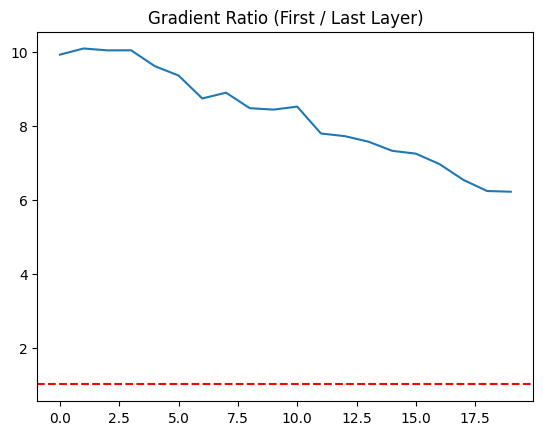

In [9]:
first = list(TRACKED_LAYERS.keys())[0]
last = list(TRACKED_LAYERS.keys())[-1]

ratio = np.array(history["epoch_grad_norms"][first]) / (
        np.array(history["epoch_grad_norms"][last]) + 1e-10)

plt.plot(ratio)
plt.axhline(1.0, color="red", linestyle="--")
plt.title("Gradient Ratio (First / Last Layer)")
plt.show()

In [10]:
# ==============================
# ALL PLOTS IN ONE CELL
# ==============================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

layer_names = list(TRACKED_LAYERS.keys())

# ------------------------------------------------
# 1. LOSS CURVES
# ------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["test_loss"], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves (Plain ResNet - No Skip)")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------
# 2. ACCURACY CURVES
# ------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["test_acc"], label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curves (Plain ResNet - No Skip)")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------
# 3. EPOCH GRADIENT NORMS (LOG SCALE)
# ------------------------------------------------
plt.figure(figsize=(10,6))
for name in layer_names:
    plt.plot(history["epoch_grad_norms"][name], label=name)

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Gradient Norm (L2)")
plt.title("Per-Epoch Gradient Norms (Log Scale)")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------
# 4. WEIGHT NORMS
# ------------------------------------------------
plt.figure(figsize=(10,6))
for name in layer_names:
    plt.plot(history["weight_norms"][name], label=name)

plt.xlabel("Epoch")
plt.ylabel("Weight Norm (L2)")
plt.title("Weight Norms Over Training")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------
# 5. WEIGHT DELTAS (LOG SCALE)
# ------------------------------------------------
plt.figure(figsize=(10,6))
for name in layer_names:
    plt.plot(history["weight_deltas"][name], label=name)

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Weight Delta (L2)")
plt.title("Weight Update Magnitude Per Epoch")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------
# 6. GRADIENT HEATMAP
# ------------------------------------------------
data = np.array([history["epoch_grad_norms"][name]
                 for name in layer_names])

plt.figure(figsize=(10,5))
plt.imshow(data, aspect="auto", cmap="YlOrRd")
plt.colorbar(label="Gradient Norm (L2)")
plt.yticks(range(len(layer_names)), layer_names)
plt.xlabel("Epoch")
plt.title("Gradient Norm Heatmap (Layers × Epochs)")
plt.show()


# ------------------------------------------------
# 7. GRADIENT RATIO (FIRST / LAST)
# ------------------------------------------------
first = layer_names[0]
last = layer_names[-1]

ratio = np.array(history["epoch_grad_norms"][first]) / (
        np.array(history["epoch_grad_norms"][last]) + 1e-10)

plt.figure(figsize=(8,5))
plt.plot(ratio)
plt.axhline(1.0, color="red", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Gradient Ratio")
plt.title("Gradient Ratio (First Layer / Last Layer)")
plt.grid(True)
plt.show()


# ------------------------------------------------
# 8. CONFUSION MATRIX
# ------------------------------------------------
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

KeyError: 'train_loss'

<Figure size 800x500 with 0 Axes>

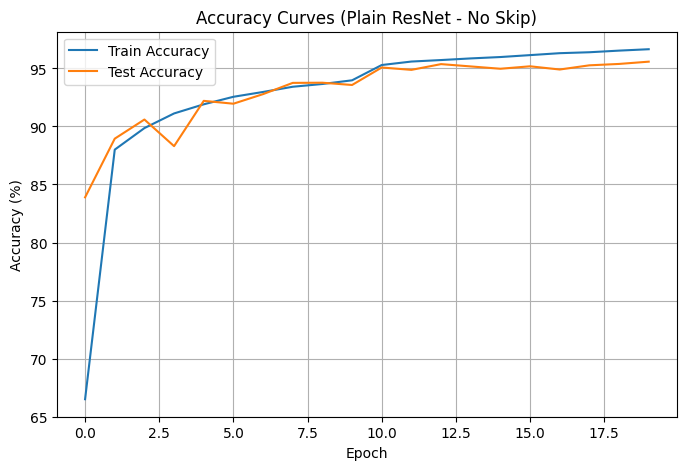

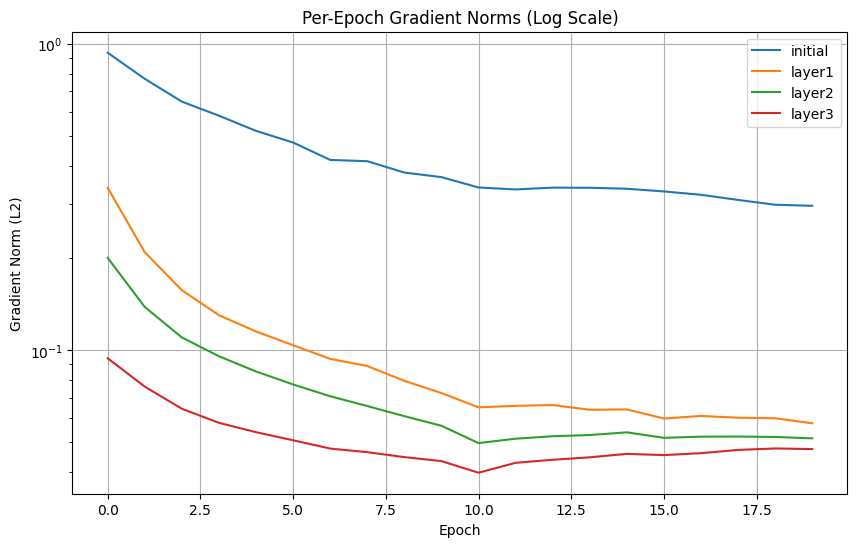

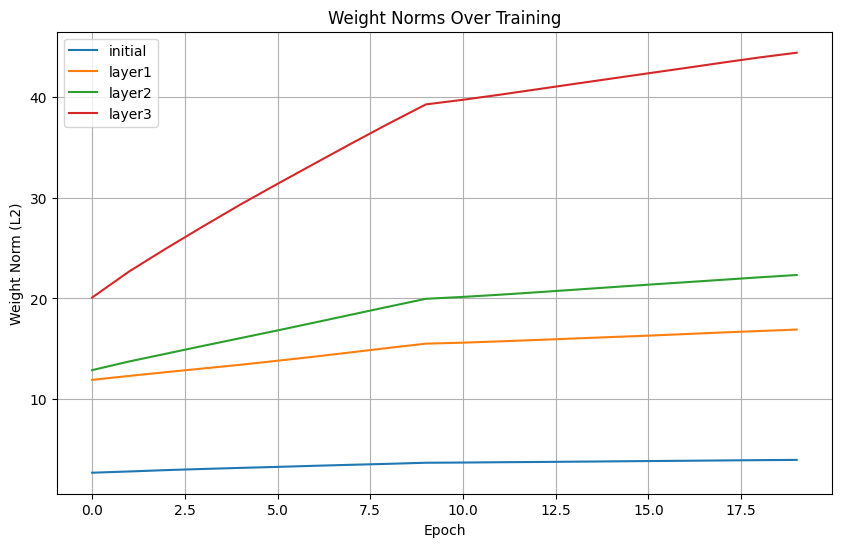

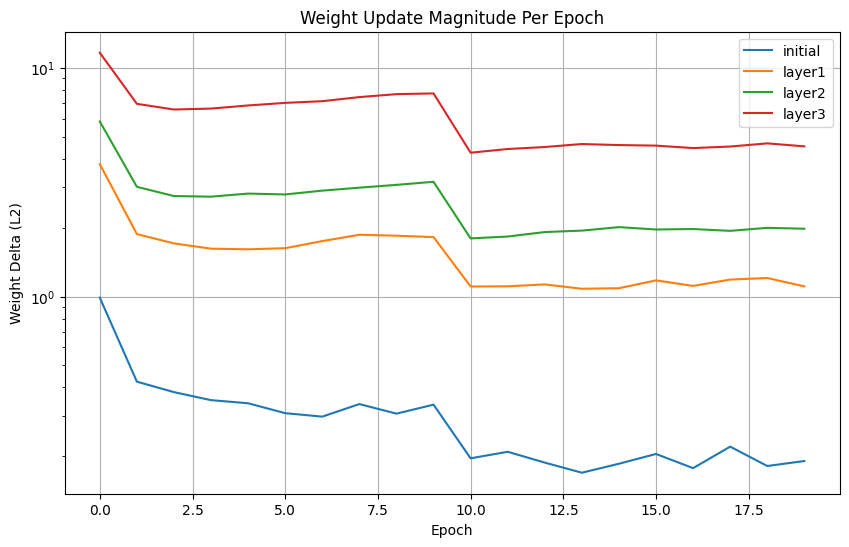

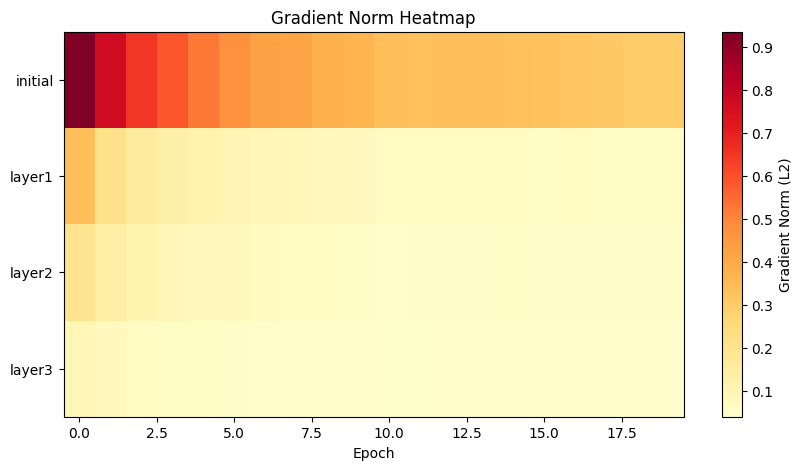

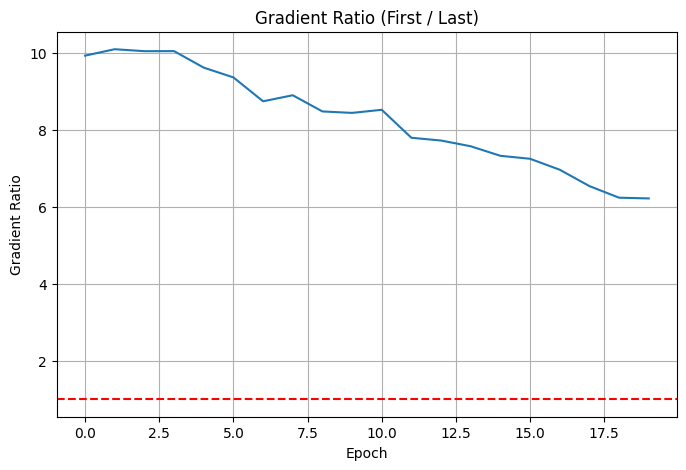

Confusion matrix skipped (predictions not stored).


In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

layer_names = list(TRACKED_LAYERS.keys())

# ------------------------------------------------
# 1. ACCURACY CURVES
# ------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["test_acc"], label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curves (Plain ResNet - No Skip)")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------
# 2. EPOCH GRADIENT NORMS (LOG SCALE)
# ------------------------------------------------
plt.figure(figsize=(10,6))
for name in layer_names:
    plt.plot(history["epoch_grad_norms"][name], label=name)

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Gradient Norm (L2)")
plt.title("Per-Epoch Gradient Norms (Log Scale)")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------
# 3. WEIGHT NORMS
# ------------------------------------------------
plt.figure(figsize=(10,6))
for name in layer_names:
    plt.plot(history["weight_norms"][name], label=name)

plt.xlabel("Epoch")
plt.ylabel("Weight Norm (L2)")
plt.title("Weight Norms Over Training")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------
# 4. WEIGHT DELTAS (LOG SCALE)
# ------------------------------------------------
plt.figure(figsize=(10,6))
for name in layer_names:
    plt.plot(history["weight_deltas"][name], label=name)

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Weight Delta (L2)")
plt.title("Weight Update Magnitude Per Epoch")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------
# 5. GRADIENT HEATMAP
# ------------------------------------------------
data = np.array([history["epoch_grad_norms"][name]
                 for name in layer_names])

plt.figure(figsize=(10,5))
plt.imshow(data, aspect="auto", cmap="YlOrRd")
plt.colorbar(label="Gradient Norm (L2)")
plt.yticks(range(len(layer_names)), layer_names)
plt.xlabel("Epoch")
plt.title("Gradient Norm Heatmap")
plt.show()


# ------------------------------------------------
# 6. GRADIENT RATIO
# ------------------------------------------------
first = layer_names[0]
last = layer_names[-1]

ratio = np.array(history["epoch_grad_norms"][first]) / (
        np.array(history["epoch_grad_norms"][last]) + 1e-10)

plt.figure(figsize=(8,5))
plt.plot(ratio)
plt.axhline(1.0, color="red", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Gradient Ratio")
plt.title("Gradient Ratio (First / Last)")
plt.grid(True)
plt.show()


# ------------------------------------------------
# 7. CONFUSION MATRIX (if available)
# ------------------------------------------------
try:
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()
except:
    print("Confusion matrix skipped (predictions not stored).")

GENERATING ALL WEIGHT MATRICES

Layer: initial.0
Shape: (64, 3, 3, 3)
L2 Norm: 3.9541

Layer: layer1.0.conv1
Shape: (64, 64, 3, 3)
L2 Norm: 16.9029

Layer: layer1.0.conv2
Shape: (64, 64, 3, 3)
L2 Norm: 17.1826

Layer: layer1.1.conv1
Shape: (64, 64, 3, 3)
L2 Norm: 17.3370

Layer: layer1.1.conv2
Shape: (64, 64, 3, 3)
L2 Norm: 17.4359

Layer: layer1.2.conv1
Shape: (64, 64, 3, 3)
L2 Norm: 17.5788

Layer: layer1.2.conv2
Shape: (64, 64, 3, 3)
L2 Norm: 17.8972

Layer: layer2.0.conv1
Shape: (128, 64, 3, 3)
L2 Norm: 22.3232

Layer: layer2.0.conv2
Shape: (128, 128, 3, 3)
L2 Norm: 32.6760

Layer: layer2.1.conv1
Shape: (128, 128, 3, 3)
L2 Norm: 33.4563

Layer: layer2.1.conv2
Shape: (128, 128, 3, 3)
L2 Norm: 34.2353

Layer: layer2.2.conv1
Shape: (128, 128, 3, 3)
L2 Norm: 34.3991

Layer: layer2.2.conv2
Shape: (128, 128, 3, 3)
L2 Norm: 34.1468

Layer: layer3.0.conv1
Shape: (256, 128, 3, 3)
L2 Norm: 44.4093

Layer: layer3.0.conv2
Shape: (256, 256, 3, 3)
L2 Norm: 64.7448

Layer: layer3.1.conv1
Shape: (

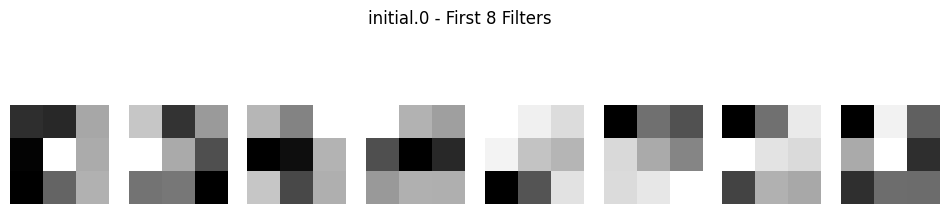


All weight matrices saved as: all_model_weights.npz


In [12]:
import numpy as np
import matplotlib.pyplot as plt

print("="*60)
print("GENERATING ALL WEIGHT MATRICES")
print("="*60)

all_weights = {}

# -------------------------------------------------------
# 1️⃣ Extract All Conv + Linear Weight Matrices
# -------------------------------------------------------
for name, module in model.named_modules():
    if isinstance(module, (torch.nn.Conv2d, torch.nn.Linear)):
        weights = module.weight.data.cpu().numpy()
        all_weights[name] = weights

        print(f"\nLayer: {name}")
        print(f"Shape: {weights.shape}")
        print(f"L2 Norm: {np.linalg.norm(weights):.4f}")

print("\nTotal weight matrices extracted:", len(all_weights))


# -------------------------------------------------------
# 2️⃣ Visualize First Few Convolution Filters
# -------------------------------------------------------
print("\nVisualizing first convolution filters...\n")

for name, weights in all_weights.items():
    if len(weights.shape) == 4:  # Conv layer
        print(f"Visualizing layer: {name}")

        num_filters = min(8, weights.shape[0])

        plt.figure(figsize=(12,3))
        for i in range(num_filters):
            plt.subplot(1, num_filters, i+1)

            # Take first input channel
            filter_img = weights[i, 0, :, :]

            plt.imshow(filter_img, cmap='gray')
            plt.axis('off')

        plt.suptitle(f"{name} - First {num_filters} Filters")
        plt.show()

        break  # remove break if you want all conv layers visualized


# -------------------------------------------------------
# 3️⃣ Save All Weight Matrices (Optional)
# -------------------------------------------------------
np.savez("all_model_weights.npz", **all_weights)
print("\nAll weight matrices saved as: all_model_weights.npz")

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

PLOTS_DIR = os.path.join(OUTPUT_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

layer_names = list(TRACKED_LAYERS.keys())

# ============================================================
# 1️⃣ LOSS CURVES
# ============================================================
plt.figure(figsize=(10,6))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["test_loss"], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "loss_curves.png"), dpi=150)
plt.close()

# ============================================================
# 2️⃣ ACCURACY CURVES
# ============================================================
plt.figure(figsize=(10,6))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["test_acc"], label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "accuracy_curves.png"), dpi=150)
plt.close()

# ============================================================
# 3️⃣ EPOCH GRADIENT NORMS (LOG SCALE)
# ============================================================
plt.figure(figsize=(12,7))
for name in layer_names:
    plt.plot(history["epoch_grad_norms"][name], label=name)

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Gradient Norm (L2)")
plt.title("Per-Epoch Gradient Norms (Log Scale)")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "epoch_gradient_norms.png"), dpi=150)
plt.close()

# ============================================================
# 4️⃣ BATCH GRADIENT NORMS (SMOOTHED)
# ============================================================
plt.figure(figsize=(14,7))
for name in layer_names:
    norms = history["batch_grad_norms"][name]
    if len(norms) > 50:
        smoothed = np.convolve(norms, np.ones(50)/50, mode="valid")
        plt.plot(smoothed, label=name)
    else:
        plt.plot(norms, label=name)

plt.yscale("log")
plt.xlabel("Batch (Smoothed)")
plt.ylabel("Gradient Norm (L2)")
plt.title("Per-Batch Gradient Norms (Smoothed)")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "batch_gradient_norms.png"), dpi=150)
plt.close()

# ============================================================
# 5️⃣ WEIGHT NORMS
# ============================================================
plt.figure(figsize=(12,7))
for name in layer_names:
    plt.plot(history["weight_norms"][name], label=name)

plt.xlabel("Epoch")
plt.ylabel("Weight Norm (L2)")
plt.title("Weight Norms Over Training")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "weight_norms.png"), dpi=150)
plt.close()

# ============================================================
# 6️⃣ WEIGHT DELTAS
# ============================================================
plt.figure(figsize=(12,7))
for name in layer_names:
    plt.plot(history["weight_deltas"][name], label=name)

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Weight Delta (L2)")
plt.title("Weight Update Magnitude Per Epoch")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "weight_deltas.png"), dpi=150)
plt.close()

# ============================================================
# 7️⃣ GRADIENT HEATMAP
# ============================================================
data = np.array([history["epoch_grad_norms"][name] for name in layer_names])

plt.figure(figsize=(12,6))
plt.imshow(data, aspect="auto", cmap="YlOrRd")
plt.colorbar(label="Gradient Norm (L2)")
plt.yticks(range(len(layer_names)), layer_names)
plt.xlabel("Epoch")
plt.title("Gradient Norm Heatmap (Layers × Epochs)")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "gradient_heatmap.png"), dpi=150)
plt.close()

# ============================================================
# 8️⃣ GRADIENT RATIO (FIRST / LAST)
# ============================================================
first = layer_names[0]
last = layer_names[-1]

ratio = np.array(history["epoch_grad_norms"][first]) / (
        np.array(history["epoch_grad_norms"][last]) + 1e-10)

plt.figure(figsize=(10,6))
plt.plot(ratio)
plt.axhline(1.0, color="red", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Gradient Ratio")
plt.title("Gradient Ratio (First Layer / Last Layer)")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "gradient_ratio.png"), dpi=150)
plt.close()

# ============================================================
# 9️⃣ CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "confusion_matrix.png"), dpi=150)
plt.close()

print("✅ All visualizations saved in:", PLOTS_DIR)

KeyError: 'train_loss'

<Figure size 1000x600 with 0 Axes>

In [14]:
history = {
    "train_loss": [],
    "test_loss": [],
    "train_acc": [],
    "test_acc": [],
    "batch_grad_norms": {k: [] for k in TRACKED_LAYERS},
    "epoch_grad_norms": {k: [] for k in TRACKED_LAYERS},
    "weight_norms": {k: [] for k in TRACKED_LAYERS},
    "weight_deltas": {k: [] for k in TRACKED_LAYERS},
}

In [15]:
def train_epoch():
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    batch_grad_accumulator = defaultdict(list)

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        # -----------------------------
        # Batch Gradient Norm Tracking
        # -----------------------------
        for name, layer in TRACKED_LAYERS.items():
            if layer.weight.grad is not None:
                grad_norm = layer.weight.grad.norm(2).item()
                batch_grad_accumulator[name].append(grad_norm)
                history["batch_grad_norms"][name].append(grad_norm)

        optimizer.step()

        running_loss += loss.item()

        _, pred = outputs.max(1)
        total += labels.size(0)
        correct += pred.eq(labels).sum().item()

    # -----------------------------
    # Epoch Statistics
    # -----------------------------
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    history["train_loss"].append(epoch_loss)
    history["train_acc"].append(epoch_acc)

    # -----------------------------
    # Epoch Gradient Norm Mean
    # -----------------------------
    for name in TRACKED_LAYERS:
        mean_grad = np.mean(batch_grad_accumulator[name])
        history["epoch_grad_norms"][name].append(mean_grad)

        # Weight Norm
        weight_norm = TRACKED_LAYERS[name].weight.data.norm(2).item()
        history["weight_norms"][name].append(weight_norm)

        # Weight Delta
        delta = (TRACKED_LAYERS[name].weight.data -
                 prev_weights[name]).norm(2).item()
        history["weight_deltas"][name].append(delta)
        prev_weights[name] = TRACKED_LAYERS[name].weight.data.clone()

    return epoch_loss, epoch_acc

In [16]:
def test_epoch():
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, pred = outputs.max(1)
            total += labels.size(0)
            correct += pred.eq(labels).sum().item()

            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(test_loader)
    epoch_acc = 100 * correct / total

    history["test_loss"].append(epoch_loss)
    history["test_acc"].append(epoch_acc)

    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels)

In [17]:
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_epoch()
    test_loss, test_acc, all_preds, all_labels = test_epoch()

    scheduler.step()

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.2f}%")


Epoch 1/20


100%|██████████| 573/573 [01:03<00:00,  9.07it/s]


Train Loss: 0.0952 | Train Acc: 97.48%
Test  Loss: 0.1594 | Test  Acc: 95.74%

Epoch 2/20


100%|██████████| 573/573 [01:04<00:00,  8.93it/s]


Train Loss: 0.0887 | Train Acc: 97.62%
Test  Loss: 0.1676 | Test  Acc: 95.71%

Epoch 3/20


...

Train Loss: 0.0369 | Train Acc: 99.06%
Test  Loss: 0.2003 | Test  Acc: 95.87%

Epoch 19/20


100%|██████████| 573/573 [01:04<00:00,  8.83it/s]


Train Loss: 0.0352 | Train Acc: 99.06%
Test  Loss: 0.2130 | Test  Acc: 95.57%

Epoch 20/20


100%|██████████| 573/573 [01:05<00:00,  8.81it/s]


Train Loss: 0.0329 | Train Acc: 99.13%
Test  Loss: 0.2106 | Test  Acc: 95.79%


In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

PLOTS_DIR = os.path.join(OUTPUT_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

layer_names = list(TRACKED_LAYERS.keys())

print("Generating visualizations...")

# ============================================================
# LOSS CURVES (only if available)
# ============================================================
if "train_loss" in history and "test_loss" in history:
    plt.figure(figsize=(10,6))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["test_loss"], label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "loss_curves.png"), dpi=150)
    plt.close()
else:
    print("⚠ Loss curves skipped (not stored in history).")


# ============================================================
# ACCURACY CURVES
# ============================================================
plt.figure(figsize=(10,6))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["test_acc"], label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "accuracy_curves.png"), dpi=150)
plt.close()


# ============================================================
# EPOCH GRADIENT NORMS
# ============================================================
plt.figure(figsize=(12,7))
for name in layer_names:
    plt.plot(history["epoch_grad_norms"][name], label=name)

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Gradient Norm (L2)")
plt.title("Per-Epoch Gradient Norms")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "epoch_gradient_norms.png"), dpi=150)
plt.close()


# ============================================================
# WEIGHT NORMS
# ============================================================
plt.figure(figsize=(12,7))
for name in layer_names:
    plt.plot(history["weight_norms"][name], label=name)

plt.xlabel("Epoch")
plt.ylabel("Weight Norm (L2)")
plt.title("Weight Norms")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "weight_norms.png"), dpi=150)
plt.close()


# ============================================================
# WEIGHT DELTAS
# ============================================================
plt.figure(figsize=(12,7))
for name in layer_names:
    plt.plot(history["weight_deltas"][name], label=name)

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Weight Delta (L2)")
plt.title("Weight Update Magnitude")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "weight_deltas.png"), dpi=150)
plt.close()


# ============================================================
# GRADIENT HEATMAP
# ============================================================
data = np.array([history["epoch_grad_norms"][name]
                 for name in layer_names])

plt.figure(figsize=(12,6))
plt.imshow(data, aspect="auto", cmap="YlOrRd")
plt.colorbar(label="Gradient Norm (L2)")
plt.yticks(range(len(layer_names)), layer_names)
plt.xlabel("Epoch")
plt.title("Gradient Norm Heatmap")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "gradient_heatmap.png"), dpi=150)
plt.close()


# ============================================================
# GRADIENT RATIO
# ============================================================
first = layer_names[0]
last = layer_names[-1]

ratio = np.array(history["epoch_grad_norms"][first]) / (
        np.array(history["epoch_grad_norms"][last]) + 1e-10)

plt.figure(figsize=(10,6))
plt.plot(ratio)
plt.axhline(1.0, color="red", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Gradient Ratio")
plt.title("Gradient Ratio (First / Last)")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "gradient_ratio.png"), dpi=150)
plt.close()


# ============================================================
# CONFUSION MATRIX (if available)
# ============================================================
if "all_preds" in globals() and "all_labels" in globals():
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "confusion_matrix.png"), dpi=150)
    plt.close()
else:
    print("⚠ Confusion matrix skipped (predictions not stored).")

print("✅ All available visualizations saved to:", PLOTS_DIR)

Generating visualizations...
✅ All available visualizations saved to: colab_resnet_wo_skip/plots


In [19]:
import json
import os
import numpy as np

OUTPUT_DIR = "outputs_resnet_wo_skip"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def convert_to_serializable(obj):
    """
    Recursively convert numpy/tensor types to JSON serializable types.
    """
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, np.float32) or isinstance(obj, np.float64):
        return float(obj)
    elif isinstance(obj, np.int32) or isinstance(obj, np.int64):
        return int(obj)
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(i) for i in obj]
    else:
        return obj

# -------------------------------------------------------
# Create full structured JSON
# -------------------------------------------------------
history_json = {
    "model": "Plain ResNet-20 (No Skip Connections)",
    "dataset": "SVHN",
    "epochs": len(history["train_acc"]),
    "metrics": {
        "train_loss": history.get("train_loss", []),
        "test_loss": history.get("test_loss", []),
        "train_accuracy": history.get("train_acc", []),
        "test_accuracy": history.get("test_acc", []),
    },
    "gradient_analysis": {
        "batch_gradient_norms": history.get("batch_grad_norms", {}),
        "epoch_gradient_norms": history.get("epoch_grad_norms", {}),
    },
    "weight_analysis": {
        "weight_norms": history.get("weight_norms", {}),
        "weight_deltas": history.get("weight_deltas", {}),
    }
}

# Convert to JSON-safe format
history_json = convert_to_serializable(history_json)

# Save file
json_path = os.path.join(OUTPUT_DIR, "training_history_complete.json")

with open(json_path, "w") as f:
    json.dump(history_json, f, indent=4)

print("✅ Complete training history saved to:")
print(json_path)

✅ Complete training history saved to:
outputs_resnet_wo_skip/training_history_complete.json
